## Importing the Files

In [1]:
import numpy as np;
import pandas as pd;

generation_data = pd.read_csv("../Raw Datas/Plant_1_Generation_Data.csv");
weather_sensor_data = pd.read_csv("../Raw Datas/Plant_1_Weather_Sensor_Data.csv");

weather_sensor_data.dtypes

DATE_TIME               object
PLANT_ID                 int64
SOURCE_KEY              object
AMBIENT_TEMPERATURE    float64
MODULE_TEMPERATURE     float64
IRRADIATION            float64
dtype: object

## Changing date type of generation_data

In [2]:
if(generation_data["DATE_TIME"].dtype != "datetime64[ns]"):
    generation_data["DATE_TIME"] = pd.to_datetime(generation_data["DATE_TIME"]);

generation_data.dtypes

C:\Users\user\AppData\Local\Temp\ipykernel_16500\2762737281.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation_data["DATE_TIME"] = pd.to_datetime(generation_data["DATE_TIME"]);


DATE_TIME      datetime64[ns]
PLANT_ID                int64
SOURCE_KEY             object
DC_POWER              float64
AC_POWER              float64
DAILY_YIELD           float64
TOTAL_YIELD           float64
dtype: object

## Changing date type of weather_sensor_data

In [3]:
if(weather_sensor_data["DATE_TIME"].dtype != "datetime64[ns]"):
    weather_sensor_data["DATE_TIME"] = pd.to_datetime(weather_sensor_data["DATE_TIME"]);

weather_sensor_data.dtypes

DATE_TIME              datetime64[ns]
PLANT_ID                        int64
SOURCE_KEY                     object
AMBIENT_TEMPERATURE           float64
MODULE_TEMPERATURE            float64
IRRADIATION                   float64
dtype: object

## Merging two files on DATE_TIME

In [4]:
data = pd.merge(generation_data, weather_sensor_data, on="DATE_TIME", how="left");
data.tail(55)

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
68723,2020-06-17 23:15:00,4135001,bvBOhCH3iADSZry,0.0,0.0,5460.000000,6539009.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
68724,2020-06-17 23:15:00,4135001,iCRJl6heRkivqQ3,0.0,0.0,5957.000000,7426263.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
68725,2020-06-17 23:15:00,4135001,ih0vzX44oOqAx2f,0.0,0.0,5758.000000,6426129.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
68726,2020-06-17 23:15:00,4135001,pkci93gMrogZuBj,0.0,0.0,5952.000000,7415430.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
68727,2020-06-17 23:15:00,4135001,rGa61gmuvPhdLxV,0.0,0.0,5950.000000,7356897.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
68728,2020-06-17 23:15:00,4135001,sjndEbLyjtCKgGv,0.0,0.0,5887.000000,7261681.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
68729,2020-06-17 23:15:00,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000000,7287002.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
68730,2020-06-17 23:15:00,4135001,wCURE6d3bPkepu2,0.0,0.0,5883.000000,7028601.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
68731,2020-06-17 23:15:00,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000000,7251204.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
68732,2020-06-17 23:15:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000000,6583369.0,4135001.0,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0


## Checking null values

In [5]:
data.isnull().sum()

DATE_TIME              0
PLANT_ID_x             0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
PLANT_ID_y             4
SOURCE_KEY_y           4
AMBIENT_TEMPERATURE    4
MODULE_TEMPERATURE     4
IRRADIATION            4
dtype: int64

In [6]:
data[data['PLANT_ID_y'].isnull()]
data=data.dropna();
data.isnull().sum()

DATE_TIME              0
PLANT_ID_x             0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
PLANT_ID_y             0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

## Checking Duplicates

In [7]:
data.duplicated().sum()

np.int64(0)

## Removing useless columns [PLANT_ID_x,PLANT_ID_y,SOURCE_KEY_y]

In [8]:
data = data.drop(columns=["SOURCE_KEY_y", "PLANT_ID_y", "PLANT_ID_x"]);
data.columns

Index(['DATE_TIME', 'SOURCE_KEY_x', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD',
       'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
       'IRRADIATION'],
      dtype='object')

## Checking the outliers

In [9]:
print("DC_POWER -: \n" , data["DC_POWER"].describe());
print("AC_POER -: \n", data["AC_POWER"].describe());
print("DAILY_YIELD -: \n", data["DAILY_YIELD"].describe());
print("TOTAL_YIELD -: \n", data["TOTAL_YIELD"].describe());
print("AMBIENT_TEMPERATURE -: \n", data["AMBIENT_TEMPERATURE"].describe());
print("MODULE_TEMPERATURE -: \n", data["MODULE_TEMPERATURE"].describe());
print("IRRADIATION -: \n", data["IRRADIATION"].describe());

DC_POWER -: 
 count    68774.000000
mean      3147.177450
std       4036.441826
min          0.000000
25%          0.000000
50%        428.571429
75%       6365.468750
max      14471.125000
Name: DC_POWER, dtype: float64
AC_POER -: 
 count    68774.000000
mean       307.778375
std        394.394865
min          0.000000
25%          0.000000
50%         41.450000
75%        623.561161
max       1410.950000
Name: AC_POWER, dtype: float64
DAILY_YIELD -: 
 count    68774.000000
mean      3295.834644
std       3145.220597
min          0.000000
25%          0.000000
50%       2658.473214
75%       6274.000000
max       9163.000000
Name: DAILY_YIELD, dtype: float64
TOTAL_YIELD -: 
 count    6.877400e+04
mean     6.978728e+06
std      4.162707e+05
min      6.183645e+06
25%      6.512007e+06
50%      7.146685e+06
75%      7.268751e+06
max      7.846821e+06
Name: TOTAL_YIELD, dtype: float64
AMBIENT_TEMPERATURE -: 
 count    68774.000000
mean        25.558521
std          3.361300
min         20

## Checking faults

In [10]:
data["isfault"] = ((data["IRRADIATION"]>0.23) & (data["DC_POWER"]<1000)).astype(int) ;
data['isfault'].value_counts()
data[(data["isfault"]==1)]

,DATE_TIME,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,isfault
815,2020-05-15 09:15:00,zVJPv84UY57bAof,0.0,0.0,711.0,7116862.0,27.988362,46.617706,0.344884,1
837,2020-05-15 09:30:00,zVJPv84UY57bAof,0.0,0.0,711.0,7116862.0,27.516728,39.136326,0.249248,1
18490,2020-05-24 15:15:00,zBIq5rxdHJRwDNY,0.0,0.0,6464.0,6410945.0,33.761304,54.006864,0.476600,1
20103,2020-05-25 10:15:00,ih0vzX44oOqAx2f,0.0,0.0,1795.0,6258289.0,29.217751,53.501414,0.834157,1
46679,2020-06-07 12:15:00,bvBOhCH3iADSZry,0.0,0.0,3551.0,6476675.0,28.748334,59.987771,1.024229,1
...,...,...,...,...,...,...,...,...,...,...
61595,2020-06-14 13:45:00,bvBOhCH3iADSZry,0.0,0.0,2378.0,6520020.0,27.048904,47.960231,0.906615,1
61606,2020-06-14 14:00:00,1BY6WEcLGh8j5v7,0.0,0.0,2402.0,6466065.0,27.848916,59.386079,1.221652,1
61617,2020-06-14 14:00:00,bvBOhCH3iADSZry,0.0,0.0,2378.0,6520020.0,27.848916,59.386079,1.221652,1
65718,2020-06-16 12:30:00,zBIq5rxdHJRwDNY,0.0,0.0,3480.0,6575313.0,27.964037,45.408554,0.483400,1


## Handeling faults

In [11]:
faults = data[data["isfault"] == 1]
print(faults["SOURCE_KEY_x"].value_counts()); 

faults['hour'] = faults['DATE_TIME'].dt.hour
print(faults['hour'].value_counts().sort_index());

data.groupby('isfault')[['IRRADIATION', 'DC_POWER']].mean()

SOURCE_KEY_x
bvBOhCH3iADSZry    21
1BY6WEcLGh8j5v7    20
z9Y9gH1T5YWrNuG     7
wCURE6d3bPkepu2     6
McdE0feGgRqW7Ca     4
sjndEbLyjtCKgGv     4
zBIq5rxdHJRwDNY     3
zVJPv84UY57bAof     2
ih0vzX44oOqAx2f     1
Name: count, dtype: int64
hour
9      2
10     2
11     6
12    19
13    30
14     8
15     1
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_16500\390100164.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  faults['hour'] = faults['DATE_TIME'].dt.hour


,IRRADIATION,DC_POWER
isfault,,
0,0.231811,3150.237620
1,0.731867,55.236082


## Adding a column of difference between irridiation and dc

In [12]:
data['fault_severity'] = (data['IRRADIATION']*10000) - data['DC_POWER'] ;
data.tail(55)

,DATE_TIME,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,isfault,fault_severity
68723,2020-06-17 23:15:00,bvBOhCH3iADSZry,0.0,0.0,5460.000000,6539009.0,22.008275,20.709211,0.0,0,0.0
68724,2020-06-17 23:15:00,iCRJl6heRkivqQ3,0.0,0.0,5957.000000,7426263.0,22.008275,20.709211,0.0,0,0.0
68725,2020-06-17 23:15:00,ih0vzX44oOqAx2f,0.0,0.0,5758.000000,6426129.0,22.008275,20.709211,0.0,0,0.0
68726,2020-06-17 23:15:00,pkci93gMrogZuBj,0.0,0.0,5952.000000,7415430.0,22.008275,20.709211,0.0,0,0.0
68727,2020-06-17 23:15:00,rGa61gmuvPhdLxV,0.0,0.0,5950.000000,7356897.0,22.008275,20.709211,0.0,0,0.0
68728,2020-06-17 23:15:00,sjndEbLyjtCKgGv,0.0,0.0,5887.000000,7261681.0,22.008275,20.709211,0.0,0,0.0
68729,2020-06-17 23:15:00,uHbuxQJl8lW7ozc,0.0,0.0,5967.000000,7287002.0,22.008275,20.709211,0.0,0,0.0
68730,2020-06-17 23:15:00,wCURE6d3bPkepu2,0.0,0.0,5883.000000,7028601.0,22.008275,20.709211,0.0,0,0.0
68731,2020-06-17 23:15:00,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000000,7251204.0,22.008275,20.709211,0.0,0,0.0
68732,2020-06-17 23:15:00,zBIq5rxdHJRwDNY,0.0,0.0,5817.000000,6583369.0,22.008275,20.709211,0.0,0,0.0


## Adding performance ratio

In [31]:
max_observed_power = data["AC_POWER"].max() ;
data["Performance_Ratio"] = (data["AC_POWER"]/max_observed_power)*100 ;
data[data["Performance_Ratio"]>0]

,DATE_TIME,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,isfault,fault_severity,Performance_Ratio
510,2020-05-15 06:00:00,1BY6WEcLGh8j5v7,37.142857,3.585714,0.000000,6259559.000,24.088446,22.206757,0.005887,0,21.726715,0.254135
511,2020-05-15 06:00:00,1IF53ai7Xc0U56Y,53.500000,5.162500,0.000000,6183645.000,24.088446,22.206757,0.005887,0,5.369572,0.365888
512,2020-05-15 06:00:00,3PZuoBAID5Wc2HD,58.000000,5.585714,0.000000,6987759.000,24.088446,22.206757,0.005887,0,0.869572,0.395883
513,2020-05-15 06:00:00,7JYdWkrLSPkdwr4,58.428571,5.628571,0.000000,7602960.000,24.088446,22.206757,0.005887,0,0.441000,0.398921
514,2020-05-15 06:00:00,McdE0feGgRqW7Ca,54.375000,5.250000,0.000000,7158964.000,24.088446,22.206757,0.005887,0,4.494572,0.372090
...,...,...,...,...,...,...,...,...,...,...,...,...
68311,2020-06-17 18:30:00,uHbuxQJl8lW7ozc,79.000000,7.614286,5966.142857,7287001.143,23.840239,22.968658,0.007007,0,-8.931102,0.539657
68312,2020-06-17 18:30:00,wCURE6d3bPkepu2,75.714286,7.300000,5882.714286,7028600.714,23.840239,22.968658,0.007007,0,-5.645388,0.517382
68313,2020-06-17 18:30:00,z9Y9gH1T5YWrNuG,77.428571,7.471429,5818.428571,7251203.429,23.840239,22.968658,0.007007,0,-7.359673,0.529532
68314,2020-06-17 18:30:00,zBIq5rxdHJRwDNY,74.857143,7.228571,5816.142857,6583368.143,23.840239,22.968658,0.007007,0,-4.788245,0.512319


## Exporting the data

In [34]:
data.to_csv("../Cleaned Datas/Cleaned_SolarData.csv",index=False);

## Checking Co-Relation between AC and DC

In [36]:
data[["DC_POWER", "AC_POWER"]].corr()

,DC_POWER,AC_POWER
DC_POWER,1.000000,0.999996
AC_POWER,0.999996,1.000000


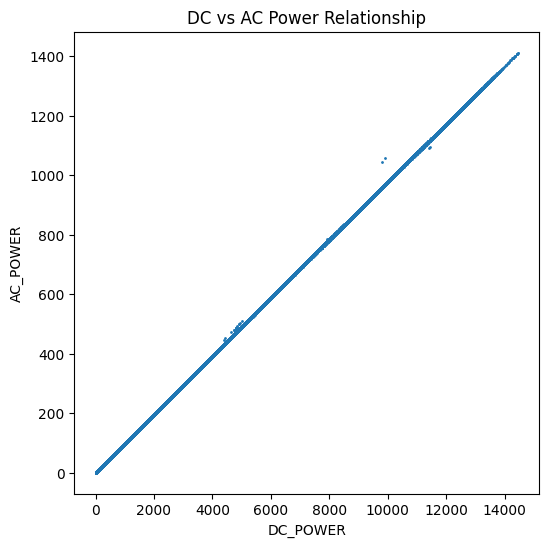

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(data["DC_POWER"], data["AC_POWER"], s=1)

plt.title("DC vs AC Power Relationship")
plt.xlabel("DC_POWER")
plt.ylabel("AC_POWER")
plt.show()